# Chapter 10.6: Meta's Production Stack

## Learning Objectives

By the end of this notebook, you will be able to:

1. Trace the **evolution** of Meta's recommendation architecture from monolith to microservices
2. Implement a simplified **DLRM** (Deep Learning Recommendation Model) and understand its design decisions
3. Understand **Zion/ZionEX**: Meta's training platform for trillion-parameter models
4. Describe Meta's **GPU serving infrastructure** for News Feed, Reels, and Ads
5. Understand how **HSTU** (Hierarchical Sequential Transduction Units) is deployed at scale
6. Analyze the **feature platform** and **experiment platform** that support Meta's rec systems
7. Draw connections between Meta's architecture choices and general production best practices

## Prerequisites

- Deep learning fundamentals (embeddings, MLPs, attention)
- Chapter 10.1-10.5 (Serving, optimization, monitoring)
- Familiarity with recommendation model architectures

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part10/chapter_10.6_meta_stack.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part10/chapter_10.6_meta_stack.ipynb)

In [1]:
import numpy as np
import time
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

print("All imports successful!")

All imports successful!


## 1. Evolution of Meta's Recommendation Architecture

Meta's rec system has evolved through several generations:

| Era | Period | Architecture | Scale |
|-----|--------|-------------|-------|
| Gen 1 | 2010-2014 | Edge Rank (handcrafted features + LR) | Millions of features |
| Gen 2 | 2014-2018 | Gradient Boosted Trees (GBDTs) | Billions of features |
| Gen 3 | 2018-2021 | DLRM (Deep Learning Recommendation Model) | Trillions of parameters |
| Gen 4 | 2021-present | HSTU + Generative Rec | Multi-trillion parameters |

Key architectural milestones:

- **2019**: Published DLRM architecture (Naumov et al.)
- **2020**: Moved to GPU-based training and serving
- **2021**: Introduced model parallelism for trillion-parameter models
- **2022**: Zion training platform for distributed training
- **2023**: HSTU (generative recommendations) in production
- **2024**: Scaling to multi-modal inputs (text, image, video)

> **💡 Concept:** Meta processes over 10 trillion predictions per day across News Feed, Reels, Stories, Ads, and People You May Know. This is the largest recommendation system in the world by prediction volume.

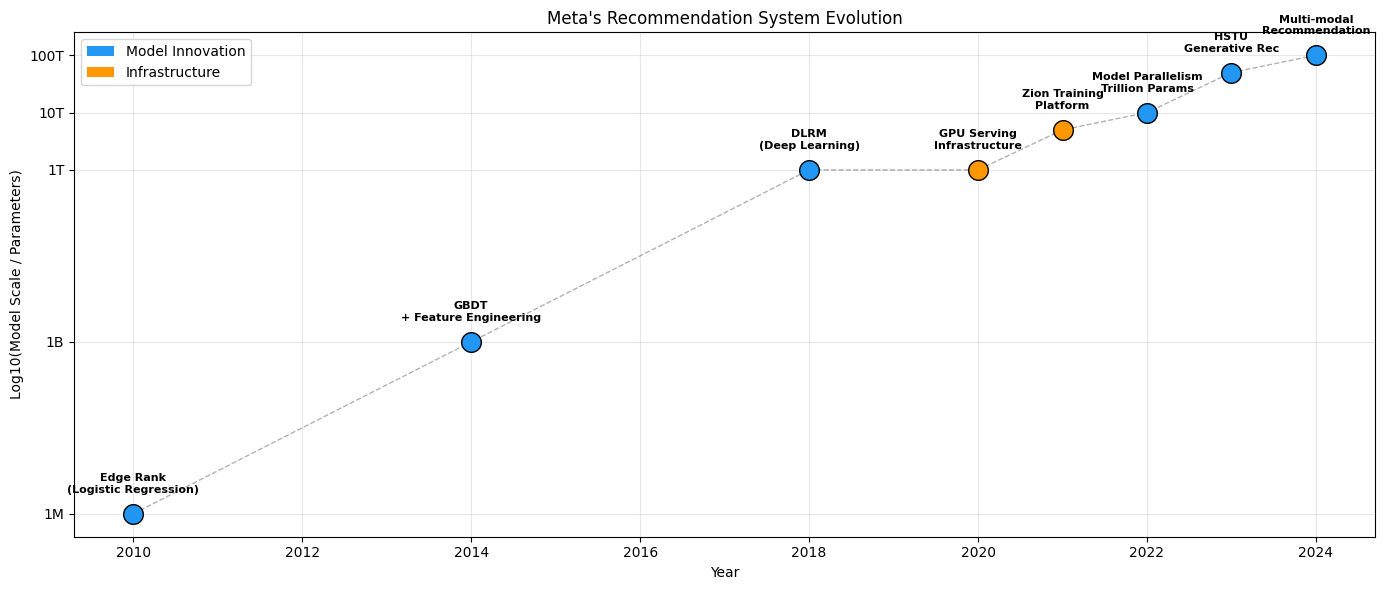

In [2]:
# Visualize Meta's architecture evolution

fig, ax = plt.subplots(figsize=(14, 6))

# Timeline data
events = [
    (2010, 'Edge Rank\n(Logistic Regression)', 'model', 1e6),
    (2014, 'GBDT\n+ Feature Engineering', 'model', 1e9),
    (2018, 'DLRM\n(Deep Learning)', 'model', 1e12),
    (2020, 'GPU Serving\nInfrastructure', 'infra', 1e12),
    (2021, 'Zion Training\nPlatform', 'infra', 5e12),
    (2022, 'Model Parallelism\nTrillion Params', 'model', 1e13),
    (2023, 'HSTU\nGenerative Rec', 'model', 5e13),
    (2024, 'Multi-modal\nRecommendation', 'model', 1e14),
]

colors_ev = {'model': '#2196F3', 'infra': '#FF9800'}

for year, label, category, scale in events:
    color = colors_ev[category]
    ax.scatter(year, np.log10(scale), s=200, c=color, zorder=5,
               edgecolors='black', linewidth=1)
    ax.annotate(label, (year, np.log10(scale)),
                textcoords="offset points", xytext=(0, 15),
                ha='center', fontsize=8, fontweight='bold')

# Connect with line
years = [e[0] for e in events]
scales = [np.log10(e[3]) for e in events]
ax.plot(years, scales, 'k--', alpha=0.3, linewidth=1)

ax.set_xlabel("Year")
ax.set_ylabel("Log10(Model Scale / Parameters)")
ax.set_title("Meta's Recommendation System Evolution")
ax.set_yticks([6, 9, 12, 13, 14])
ax.set_yticklabels(['1M', '1B', '1T', '10T', '100T'])

legend_elements = [
    mpatches.Patch(facecolor='#2196F3', label='Model Innovation'),
    mpatches.Patch(facecolor='#FF9800', label='Infrastructure'),
]
ax.legend(handles=legend_elements)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. DLRM Architecture Deep Dive

**DLRM** (Naumov et al., 2019) is Meta's foundational deep recommendation architecture. Key design choices:

1. **Embedding tables** for categorical features (most of the parameters)
2. **Bottom MLP** for dense features
3. **Feature interaction** via dot products between all embedding pairs
4. **Top MLP** for final prediction

Architecture:

$$
\hat{y} = \sigma\left(\text{TopMLP}\left([\text{concat}(e_1, e_2, ..., e_k, \text{BottomMLP}(x_{\text{dense}})), \text{interactions}]\right)\right)
$$

where interactions are pairwise dot products:

$$
\text{interactions}_{i,j} = e_i^T \cdot e_j \quad \forall i < j
$$

Key insight: Embedding tables consume 99%+ of model parameters but <10% of compute. MLPs consume <1% of parameters but >90% of compute. This drives the **model parallel** + **data parallel** hybrid training strategy.

> **⚠️ Common Pitfall:** DLRM's pairwise feature interactions grow as $O(k^2)$ where $k$ is the number of features. With hundreds of features, this creates a bottleneck. DCN-v2 (Wang et al., 2021, Google) addresses this with cross networks that are $O(k)$.

In [3]:
# Implement a simplified DLRM

class EmbeddingTable:
    """Simulates a hash-based embedding table."""

    def __init__(self, num_embeddings: int, embedding_dim: int):
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.weight = np.random.randn(num_embeddings, embedding_dim).astype(np.float32) * 0.01

    def lookup(self, indices: np.ndarray) -> np.ndarray:
        """Look up embeddings for given indices."""
        indices = indices % self.num_embeddings  # Hash-based collision
        return self.weight[indices]

    @property
    def num_parameters(self) -> int:
        return self.weight.size


class MLP:
    """Multi-layer perceptron."""

    def __init__(self, dims: List[int]):
        self.layers = []
        for i in range(len(dims) - 1):
            W = np.random.randn(dims[i], dims[i+1]).astype(np.float32) * 0.01
            b = np.zeros(dims[i+1], dtype=np.float32)
            self.layers.append((W, b))

    def forward(self, x: np.ndarray) -> np.ndarray:
        for i, (W, b) in enumerate(self.layers):
            x = x @ W + b
            if i < len(self.layers) - 1:  # ReLU except last layer
                x = np.maximum(x, 0)
        return x

    @property
    def num_parameters(self) -> int:
        return sum(W.size + b.size for W, b in self.layers)


class DLRM:
    """Simplified Deep Learning Recommendation Model.

    Reference: Naumov et al., 'Deep Learning Recommendation Model
    for Personalization and Recommendation Systems' (2019, Meta)
    """

    def __init__(self, num_dense_features: int, embedding_configs: List[Tuple[int, int]],
                 bottom_mlp_dims: List[int], top_mlp_dims: List[int]):
        """
        Args:
            num_dense_features: Number of dense input features
            embedding_configs: List of (num_embeddings, embedding_dim)
            bottom_mlp_dims: Dimensions for bottom MLP (dense feature processing)
            top_mlp_dims: Dimensions for top MLP (final prediction)
        """
        # Embedding tables for categorical features
        self.embedding_tables = [
            EmbeddingTable(num_emb, emb_dim)
            for num_emb, emb_dim in embedding_configs
        ]

        # Bottom MLP (processes dense features)
        emb_dim = embedding_configs[0][1]  # All embeddings same dim
        self.bottom_mlp = MLP([num_dense_features] + bottom_mlp_dims + [emb_dim])

        # Top MLP (processes interactions)
        n_features = len(embedding_configs) + 1  # +1 for bottom MLP output
        n_interactions = n_features * (n_features - 1) // 2
        top_input_dim = n_interactions + emb_dim
        self.top_mlp = MLP([top_input_dim] + top_mlp_dims + [1])

        self.n_features = n_features

    def compute_interactions(self, embeddings: List[np.ndarray]) -> np.ndarray:
        """Compute pairwise dot-product interactions."""
        batch_size = embeddings[0].shape[0]
        interactions = []

        for i in range(len(embeddings)):
            for j in range(i + 1, len(embeddings)):
                # Dot product between feature i and feature j
                dot = np.sum(embeddings[i] * embeddings[j], axis=1, keepdims=True)
                interactions.append(dot)

        return np.concatenate(interactions, axis=1)

    def forward(self, dense_features: np.ndarray,
                sparse_features: List[np.ndarray]) -> np.ndarray:
        """
        Forward pass.

        Args:
            dense_features: (batch_size, num_dense_features)
            sparse_features: List of (batch_size,) int arrays
        """
        # Bottom MLP processes dense features
        dense_emb = self.bottom_mlp.forward(dense_features)

        # Embedding lookups for sparse features
        sparse_embs = [
            table.lookup(indices)
            for table, indices in zip(self.embedding_tables, sparse_features)
        ]

        # All embeddings (dense MLP output + sparse embeddings)
        all_embeddings = [dense_emb] + sparse_embs

        # Compute pairwise interactions
        interactions = self.compute_interactions(all_embeddings)

        # Concatenate dense embedding with interactions
        top_input = np.concatenate([dense_emb, interactions], axis=1)

        # Top MLP for final prediction
        logit = self.top_mlp.forward(top_input)

        # Sigmoid for probability
        return 1.0 / (1.0 + np.exp(-np.clip(logit, -20, 20)))

    @property
    def num_parameters(self) -> int:
        emb_params = sum(t.num_parameters for t in self.embedding_tables)
        mlp_params = self.bottom_mlp.num_parameters + self.top_mlp.num_parameters
        return emb_params + mlp_params

    @property
    def num_embedding_parameters(self) -> int:
        return sum(t.num_parameters for t in self.embedding_tables)

    @property
    def num_mlp_parameters(self) -> int:
        return self.bottom_mlp.num_parameters + self.top_mlp.num_parameters


# Create a DLRM model with realistic proportions
np.random.seed(42)

embedding_dim = 32
embedding_configs = [
    (100000, embedding_dim),  # User ID
    (50000, embedding_dim),   # Item ID
    (1000, embedding_dim),    # Category
    (500, embedding_dim),     # City
    (7, embedding_dim),       # Day of week
    (24, embedding_dim),      # Hour of day
    (100, embedding_dim),     # Device type
    (50, embedding_dim),      # OS
]

model = DLRM(
    num_dense_features=13,
    embedding_configs=embedding_configs,
    bottom_mlp_dims=[64, 32],
    top_mlp_dims=[256, 128, 64]
)

print(f"DLRM Model Summary:")
print(f"  Total parameters: {model.num_parameters:,}")
print(f"  Embedding parameters: {model.num_embedding_parameters:,} "
      f"({model.num_embedding_parameters/model.num_parameters:.1%})")
print(f"  MLP parameters: {model.num_mlp_parameters:,} "
      f"({model.num_mlp_parameters/model.num_parameters:.1%})")
print(f"  Number of feature interactions: {model.n_features * (model.n_features-1) // 2}")

# Test forward pass
batch_size = 128
dense = np.random.randn(batch_size, 13).astype(np.float32)
sparse = [np.random.randint(0, cfg[0], batch_size) for cfg in embedding_configs]

start = time.perf_counter()
predictions = model.forward(dense, sparse)
elapsed = (time.perf_counter() - start) * 1000

print(f"\nInference (batch={batch_size}): {elapsed:.2f}ms")
print(f"Predictions shape: {predictions.shape}")
print(f"Prediction range: [{predictions.min():.4f}, {predictions.max():.4f}]")

DLRM Model Summary:
  Total parameters: 4,916,705
  Embedding parameters: 4,853,792 (98.7%)
  MLP parameters: 62,913 (1.3%)
  Number of feature interactions: 36

Inference (batch=128): 1.48ms
Predictions shape: (128, 1)
Prediction range: [0.5000, 0.5000]


## 3. Zion Training Platform

**Zion** (and its successor ZionEX) is Meta's training platform for recommendation models, designed to handle:

- **Trillion-parameter models**: Embedding tables too large for a single machine
- **Petabyte-scale training data**: Daily training on billions of interactions
- **Hybrid parallelism**: Model parallelism for embeddings + data parallelism for MLPs

Training architecture:

$$
\text{Embedding Tables} \xrightarrow{\text{Model Parallel}} \text{Sharded across N machines}
$$
$$
\text{MLP Layers} \xrightarrow{\text{Data Parallel}} \text{Replicated across M GPUs}
$$

Key innovations:
- **Embedding sharding**: Each table row is assigned to a specific machine via hash
- **AllReduce for gradients**: MLP gradients are synchronized across data-parallel workers
- **Pipelined embedding lookups**: Overlap communication with computation
- **Mixed precision training**: FP16 for MLP, FP32 for embeddings (important for convergence)

> **🔑 Pro Tip:** In Meta's production setup, embedding tables account for 99.9% of model parameters but only 1% of FLOPS. This extreme imbalance is why a hybrid parallel approach is necessary -- pure data parallelism would require replicating TB-scale embeddings, and pure model parallelism would underutilize GPU compute.

In [4]:
# Simulate Zion's hybrid parallelism

@dataclass
class TrainingConfig:
    num_embedding_tables: int
    total_embedding_params: int  # In billions
    mlp_params: int  # In millions
    batch_size: int
    num_gpu_workers: int
    num_embedding_shards: int
    gpu_memory_gb: float = 80.0  # A100
    network_bandwidth_gbps: float = 400.0  # NVLink/InfiniBand


def simulate_training_step(config: TrainingConfig) -> Dict:
    """Simulate one training step with hybrid parallelism."""

    # Embedding lookup time (model parallel)
    embedding_bytes = config.total_embedding_params * 1e9 * 4  # FP32
    bytes_per_shard = embedding_bytes / config.num_embedding_shards
    # Lookup: ~0.1ms per table per shard (memory bandwidth limited)
    lookup_time_ms = config.num_embedding_tables * 0.1

    # All-to-all communication for embeddings
    # Each GPU needs embeddings from all shards
    emb_dim = 64  # Typical
    comm_bytes = config.batch_size * config.num_embedding_tables * emb_dim * 4
    alltoall_time_ms = (comm_bytes / (config.network_bandwidth_gbps * 1e9 / 8)) * 1000

    # MLP forward + backward (data parallel, GPU compute)
    flops_per_sample = config.mlp_params * 1e6 * 6  # ~6 FLOPS per param (fwd+bwd)
    total_flops = flops_per_sample * config.batch_size / config.num_gpu_workers
    gpu_tflops = 312  # A100 FP16 peak
    mlp_time_ms = (total_flops / (gpu_tflops * 1e12)) * 1000
    # Realistic utilization ~30%
    mlp_time_ms /= 0.3

    # AllReduce for MLP gradients
    grad_bytes = config.mlp_params * 1e6 * 4  # FP32 gradients
    allreduce_time_ms = (2 * grad_bytes * (config.num_gpu_workers - 1) /
                         config.num_gpu_workers /
                         (config.network_bandwidth_gbps * 1e9 / 8)) * 1000

    # Total time (some overlap possible)
    total_time_ms = lookup_time_ms + alltoall_time_ms + mlp_time_ms + allreduce_time_ms
    # Pipeline overlap reduces total by ~20%
    total_time_ms *= 0.8

    throughput = config.batch_size / (total_time_ms / 1000)  # samples/sec

    return {
        "lookup_ms": lookup_time_ms,
        "alltoall_ms": alltoall_time_ms,
        "mlp_ms": mlp_time_ms,
        "allreduce_ms": allreduce_time_ms,
        "total_ms": total_time_ms,
        "throughput_samples_sec": throughput,
    }


# Simulate different cluster sizes
configs = [
    ("Small (8 GPUs)", TrainingConfig(26, 10, 50, 4096, 8, 8)),
    ("Medium (64 GPUs)", TrainingConfig(26, 100, 100, 32768, 64, 32)),
    ("Large (256 GPUs)", TrainingConfig(26, 500, 200, 131072, 256, 128)),
    ("Meta Scale (2048 GPUs)", TrainingConfig(26, 5000, 500, 1048576, 2048, 512)),
]

print(f"{'Config':<25} | {'Total (ms)':>10} | {'Throughput':>15} | {'Lookup':>8} | {'Comm':>8} | {'MLP':>8}")
print("-" * 85)
for name, config in configs:
    result = simulate_training_step(config)
    print(f"{name:<25} | {result['total_ms']:>10.1f} | "
          f"{result['throughput_samples_sec']:>12,.0f}/s | "
          f"{result['lookup_ms']:>6.1f}ms | "
          f"{result['alltoall_ms'] + result['allreduce_ms']:>6.1f}ms | "
          f"{result['mlp_ms']:>6.1f}ms")

Config                    | Total (ms) |      Throughput |   Lookup |     Comm |      MLP
-------------------------------------------------------------------------------------
Small (8 GPUs)            |        9.4 |      434,403/s |    2.6ms |    7.5ms |    1.6ms
Medium (64 GPUs)          |       20.8 |    1,575,741/s |    2.6ms |   20.1ms |    3.3ms
Large (256 GPUs)          |       46.8 |    2,801,287/s |    2.6ms |   49.3ms |    6.6ms
Meta Scale (2048 GPUs)    |      190.8 |    5,494,354/s |    2.6ms |  219.5ms |   16.4ms


## 4. Meta's Serving Infrastructure

Meta's serving stack handles the full pipeline for multiple surfaces:

| Surface | QPS | Latency Budget | Model Size | Candidates |
|---------|-----|---------------|------------|------------|
| News Feed | ~100M/min | 200ms E2E | 100B+ params | ~10K candidates |
| Reels | ~50M/min | 150ms E2E | 100B+ params | ~5K candidates |
| Ads | ~200M/min | 100ms E2E | 1T+ params | ~1K candidates |
| PYMK | ~10M/min | 500ms E2E | 50B+ params | ~1K candidates |

The serving pipeline for each surface:
1. **Candidate generation**: Multiple retrieval models (CF, embedding-based, graph-based)
2. **Pre-ranking**: Lightweight model to reduce 10K → 500 candidates
3. **Ranking**: Full DLRM/HSTU model on GPU
4. **Re-ranking**: Business rules (diversity, content policy, ad spacing)

GPU serving uses **inference-optimized hardware** (NVIDIA T4/A10G) with:
- Dynamic batching (Triton Inference Server)
- FP16 inference
- Embedding caching on GPU memory

> **💡 Concept:** Meta's GPU inference fleet is one of the largest in the world, with tens of thousands of GPUs dedicated purely to recommendation inference. The ROI of GPU inference over CPU is justified by the quality improvement from running deeper models.

In [5]:
# Simulate Meta's multi-surface serving pipeline

@dataclass
class SurfaceConfig:
    name: str
    qps: int
    latency_budget_ms: float
    num_candidates: int
    pre_rank_to: int
    rank_to: int
    model_complexity: float  # Relative to baseline


surfaces = [
    SurfaceConfig("News Feed", 1_700_000, 200, 10000, 500, 50, 1.0),
    SurfaceConfig("Reels", 850_000, 150, 5000, 300, 30, 1.2),
    SurfaceConfig("Ads", 3_300_000, 100, 1000, 200, 20, 1.5),
    SurfaceConfig("PYMK", 170_000, 500, 1000, 100, 10, 0.8),
]


def simulate_surface_latency(config: SurfaceConfig, n_requests: int = 5000) -> Dict:
    """Simulate latency for a Meta recommendation surface."""
    results = []

    for _ in range(n_requests):
        # Candidate generation (ANN search)
        retrieval_ms = np.random.lognormal(np.log(20), 0.3) * (config.num_candidates / 5000)

        # Pre-ranking (lightweight model)
        prerank_ms = np.random.lognormal(np.log(10), 0.2) * (config.pre_rank_to / 500)

        # Full ranking (GPU inference)
        rank_ms = np.random.lognormal(np.log(15 * config.model_complexity), 0.25)

        # Re-ranking (business rules)
        rerank_ms = np.random.lognormal(np.log(5), 0.2)

        # Feature lookup (parallel with retrieval)
        feature_ms = np.random.lognormal(np.log(8), 0.3)

        # Total (feature lookup overlaps with retrieval)
        total = max(retrieval_ms, feature_ms) + prerank_ms + rank_ms + rerank_ms

        results.append({
            "retrieval": retrieval_ms,
            "prerank": prerank_ms,
            "rank": rank_ms,
            "rerank": rerank_ms,
            "total": total,
            "within_budget": total <= config.latency_budget_ms,
        })

    return results


np.random.seed(42)
surface_results = {}
for surface in surfaces:
    surface_results[surface.name] = simulate_surface_latency(surface)

print(f"{'Surface':<12} | {'QPS':>10} | {'Budget':>8} | {'P50':>8} | {'P90':>8} | {'P99':>8} | {'In SLA':>8}")
print("-" * 75)
for surface in surfaces:
    results = surface_results[surface.name]
    totals = [r["total"] for r in results]
    in_sla = sum(r["within_budget"] for r in results) / len(results)
    print(f"{surface.name:<12} | {surface.qps:>10,} | {surface.latency_budget_ms:>6.0f}ms | "
          f"{np.percentile(totals, 50):>6.1f}ms | {np.percentile(totals, 90):>6.1f}ms | "
          f"{np.percentile(totals, 99):>6.1f}ms | {in_sla:>7.1%}")

Surface      |        QPS |   Budget |      P50 |      P90 |      P99 |   In SLA
---------------------------------------------------------------------------
News Feed    |  1,700,000 |    200ms |   71.1ms |   91.0ms |  112.1ms |  100.0%
Reels        |    850,000 |    150ms |   49.9ms |   61.2ms |   74.1ms |  100.0%
Ads          |  3,300,000 |    100ms |   40.2ms |   49.4ms |   59.5ms |  100.0%
PYMK         |    170,000 |    500ms |   27.6ms |   33.6ms |   40.0ms |  100.0%


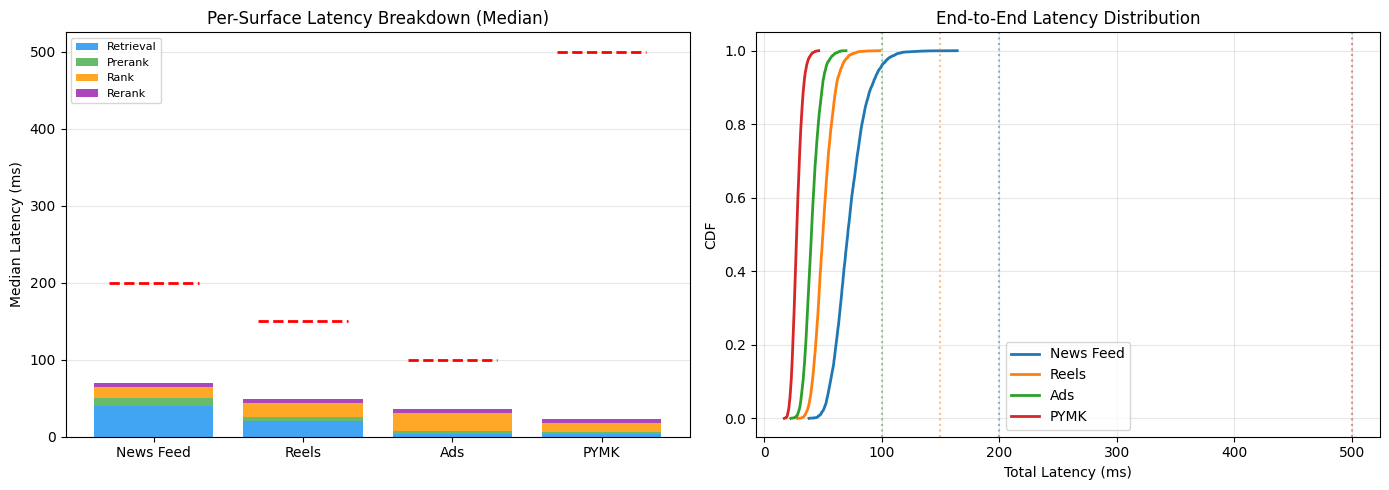

In [6]:
# Visualize serving pipeline breakdown per surface
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Stacked bar of latency breakdown
surface_names = [s.name for s in surfaces]
stages = ["retrieval", "prerank", "rank", "rerank"]
stage_colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]

x = np.arange(len(surface_names))
bottoms = np.zeros(len(surface_names))

for stage, color in zip(stages, stage_colors):
    medians = [np.median([r[stage] for r in surface_results[name]])
               for name in surface_names]
    axes[0].bar(x, medians, bottom=bottoms, label=stage.capitalize(),
                color=color, alpha=0.85)
    bottoms += medians

# Add budget line
for i, surface in enumerate(surfaces):
    axes[0].plot([i-0.3, i+0.3], [surface.latency_budget_ms]*2, 'r--', linewidth=2)

axes[0].set_xticks(x)
axes[0].set_xticklabels(surface_names)
axes[0].set_ylabel("Median Latency (ms)")
axes[0].set_title("Per-Surface Latency Breakdown (Median)")
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Right: Latency CDF per surface
for i, surface in enumerate(surfaces):
    totals = sorted([r["total"] for r in surface_results[surface.name]])
    cdf = np.linspace(0, 1, len(totals))
    axes[1].plot(totals, cdf, linewidth=2, label=surface.name)
    axes[1].axvline(x=surface.latency_budget_ms, color=f'C{i}',
                    linestyle=':', alpha=0.5)

axes[1].set_xlabel("Total Latency (ms)")
axes[1].set_ylabel("CDF")
axes[1].set_title("End-to-End Latency Distribution")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. HSTU in Production

**HSTU** (Hierarchical Sequential Transduction Units, Zhai et al. 2024) represents Meta's latest generation of recommendation models:

- **Generative recommendations**: Models the user's entire interaction sequence as a generative process
- **Sequential architecture**: Replaces the static DLRM feature interactions with sequence-to-sequence modeling
- **Trillion+ scale**: Even larger than DLRM, with attention over long user histories

Key architectural elements:

$$
h_t = \text{HSTU}(e_{a_1}, e_{a_2}, ..., e_{a_t})
$$

where $e_{a_i}$ is the embedding of the $i$-th action in the user's history, and $h_t$ is the user's representation at time $t$.

The model uses **hierarchical attention** to efficiently process sequences of length 1000+:
1. **Local attention**: Within recent interactions (last 100)
2. **Compressed attention**: Over older interactions (summarized)
3. **Cross-attention**: Between user representation and candidate items

> **💡 Concept:** HSTU is one of the first large-scale deployments of generative AI for recommendations. Unlike language models that generate text, HSTU generates the next item the user is likely to interact with, trained on the same next-token prediction objective.

In [7]:
# Simplified HSTU-inspired sequential recommendation model

class SimpleHSTU:
    """Simplified HSTU-like model for understanding the architecture.

    Reference: Zhai et al., 'Actions Speak Louder than Words:
    Trillion-Parameter Sequential Transducers for Generative Recommendations' (2024, Meta)
    """

    def __init__(self, num_items: int, embedding_dim: int = 64,
                 num_heads: int = 4, max_seq_len: int = 100):
        self.num_items = num_items
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.max_seq_len = max_seq_len
        self.head_dim = embedding_dim // num_heads

        # Item embeddings
        self.item_embeddings = np.random.randn(num_items, embedding_dim).astype(np.float32) * 0.02

        # Position embeddings
        self.pos_embeddings = np.random.randn(max_seq_len, embedding_dim).astype(np.float32) * 0.02

        # Attention parameters (simplified: single layer)
        self.W_q = np.random.randn(embedding_dim, embedding_dim).astype(np.float32) * 0.02
        self.W_k = np.random.randn(embedding_dim, embedding_dim).astype(np.float32) * 0.02
        self.W_v = np.random.randn(embedding_dim, embedding_dim).astype(np.float32) * 0.02
        self.W_o = np.random.randn(embedding_dim, embedding_dim).astype(np.float32) * 0.02

    def causal_attention(self, x: np.ndarray) -> np.ndarray:
        """Causal (masked) multi-head self-attention."""
        seq_len = x.shape[0]

        Q = x @ self.W_q  # (seq_len, dim)
        K = x @ self.W_k
        V = x @ self.W_v

        # Reshape for multi-head attention
        Q = Q.reshape(seq_len, self.num_heads, self.head_dim)
        K = K.reshape(seq_len, self.num_heads, self.head_dim)
        V = V.reshape(seq_len, self.num_heads, self.head_dim)

        # Compute attention scores
        scale = np.sqrt(self.head_dim)
        scores = np.einsum('shd,thd->sth', Q, K) / scale  # (seq, seq, heads)

        # Causal mask
        mask = np.triu(np.ones((seq_len, seq_len)), k=1) * -1e9
        scores += mask[:, :, np.newaxis]

        # Softmax
        scores_max = scores.max(axis=1, keepdims=True)
        exp_scores = np.exp(scores - scores_max)
        attn_weights = exp_scores / (exp_scores.sum(axis=1, keepdims=True) + 1e-8)

        # Apply attention to values
        output = np.einsum('sth,thd->shd', attn_weights, V)
        output = output.reshape(seq_len, self.embedding_dim)

        # Output projection
        return output @ self.W_o

    def forward(self, item_sequence: np.ndarray) -> np.ndarray:
        """Forward pass: encode a user's item interaction sequence.

        Args:
            item_sequence: (seq_len,) array of item IDs

        Returns:
            user_representation: (embedding_dim,) user vector
        """
        seq_len = min(len(item_sequence), self.max_seq_len)
        items = item_sequence[-seq_len:]  # Take most recent

        # Embed items + positions
        x = self.item_embeddings[items % self.num_items]
        x = x + self.pos_embeddings[:seq_len]

        # Self-attention
        x = x + self.causal_attention(x)  # Residual connection

        # User representation is the last hidden state
        return x[-1]

    def score_candidates(self, user_repr: np.ndarray,
                         candidate_ids: np.ndarray) -> np.ndarray:
        """Score candidate items against user representation."""
        candidates = self.item_embeddings[candidate_ids % self.num_items]
        scores = candidates @ user_repr  # Dot product
        return scores


# Create and test HSTU
np.random.seed(42)
hstu = SimpleHSTU(num_items=50000, embedding_dim=64, num_heads=4, max_seq_len=50)

# Simulate a user's interaction history
user_history = np.random.randint(0, 50000, 30)  # 30 recent interactions
candidates = np.random.randint(0, 50000, 500)    # 500 candidates to score

start = time.perf_counter()
user_repr = hstu.forward(user_history)
scores = hstu.score_candidates(user_repr, candidates)
elapsed = (time.perf_counter() - start) * 1000

print(f"HSTU Inference:")
print(f"  Sequence length: {len(user_history)}")
print(f"  Candidates scored: {len(candidates)}")
print(f"  Inference time: {elapsed:.2f}ms")
print(f"  Top-5 candidate indices: {candidates[np.argsort(-scores)[:5]]}")
print(f"  Score range: [{scores.min():.4f}, {scores.max():.4f}]")

HSTU Inference:
  Sequence length: 30
  Candidates scored: 500
  Inference time: 1.97ms
  Top-5 candidate indices: [21011 12554  1963  2625 12110]
  Score range: [-0.0114, 0.0156]


## Exercises

### 🏋️ Exercise 1: Implement DLRM with DCN-v2 Interactions

Replace DLRM's pairwise dot-product interactions with a cross network (DCN-v2) that scales linearly with the number of features.

In [8]:
# 🏋️ Exercise 1: DLRM with DCN-v2

class CrossNetwork:
    """DCN-v2 cross network for feature interactions.
    Reference: Wang et al., 'DCN V2: Improved Deep & Cross Network' (2021, Google)
    """

    def __init__(self, input_dim: int, num_layers: int = 3):
        # TODO: Initialize cross network parameters
        # Each layer: x_{l+1} = x_0 * (W_l * x_l + b_l) + x_l
        pass

    def forward(self, x: np.ndarray) -> np.ndarray:
        # TODO: Implement cross network forward pass
        pass


class DLRM_DCN(DLRM):
    """DLRM with DCN-v2 interactions instead of dot products."""

    def __init__(self, *args, **kwargs):
        # TODO: Replace dot-product interactions with CrossNetwork
        pass


# TODO: Compare DLRM vs DLRM-DCN:
# 1. Number of interaction parameters
# 2. Inference time
# 3. Scaling behavior with number of features

### 🏋️ Exercise 2: Embedding Sharding Simulator

Simulate Meta's embedding table sharding strategy and analyze the communication overhead.

In [9]:
# 🏋️ Exercise 2: Embedding sharding

# TODO: Implement a simulator that:
# 1. Distributes embedding tables across N shards
#    - Strategy 1: Table-wise sharding (each table on one shard)
#    - Strategy 2: Row-wise sharding (rows distributed across shards)
#    - Strategy 3: Column-wise sharding (embedding dim split across shards)
# 2. Simulates a training batch:
#    - Each sample needs embeddings from all tables
#    - Measure communication volume for each strategy
# 3. Compare strategies on:
#    - Memory balance across shards
#    - Communication volume
#    - Lookup latency

### 🏋️ Exercise 3: HSTU vs DLRM Comparison

Compare the DLRM and HSTU architectures on a synthetic sequential recommendation task.

In [10]:
# 🏋️ Exercise 3: DLRM vs HSTU

# TODO: Create a synthetic dataset where:
# - Users have sequential interaction patterns
# - Some items naturally follow others (sequential dependencies)
# Evaluate both DLRM (no sequence) and HSTU (with sequence):
# 1. Measure ranking quality (hit rate @ K)
# 2. Measure inference latency
# 3. Analyze when HSTU's sequential modeling helps most
#    (hint: users with diverse interests vs focused interests)

## Summary

Key takeaways from Meta's production stack:

1. **DLRM** is the foundational architecture: embedding tables (99.9% of params) + MLPs (99% of compute) with dot-product interactions
2. **Hybrid parallelism** (model parallel for embeddings + data parallel for MLPs) is essential for trillion-parameter models
3. **Multi-surface serving** requires per-surface latency budgets and model complexity tuning
4. **HSTU** represents the shift to generative/sequential recommendations, bringing transformer-like architectures to rec systems
5. The entire stack (training, serving, monitoring, experimentation) is deeply integrated -- no single component works in isolation

### References

- Naumov et al., "Deep Learning Recommendation Model for Personalization and Recommendation Systems" (2019, Meta)
- Zhai et al., "Actions Speak Louder than Words: Trillion-Parameter Sequential Transducers for Generative Recommendations" (2024, Meta)
- Hazelwood et al., "Applied Machine Learning at Facebook: A Datacenter Infrastructure Perspective" (2018, Meta)
- Mudigere et al., "Software-Hardware Co-design for Fast and Scalable Training of Deep Learning Recommendation Models" (2022, Meta)
- Acun et al., "Understanding Training Efficiency of Deep Learning Recommendation Models at Scale" (2021, Meta)